# Customer Churn Prediction — Logistic Regression

**Goal:** Predict whether a telecom customer will churn (leave) based on demographic and service-usage features.

**Dataset:** IBM Telco Churn — 200 customers, 7 features  
**Model:** Logistic Regression (scikit-learn)  
**Key metric:** Log Loss (Binary Cross-Entropy)

---

## 1 · Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    log_loss, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 2 · Load & Inspect Data

In [2]:
DATA_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
)

FEATURES = ["tenure", "age", "address", "income", "ed", "employ", "equip"]
TARGET   = "churn"

df = pd.read_csv(DATA_URL)
df = df[FEATURES + [TARGET]].copy()
df[TARGET] = df[TARGET].astype(int)

print(f"Shape  : {df.shape}")
print(f"Churn rate: {df[TARGET].mean():.1%}")
df.head()

Shape  : (200, 8)
Churn rate: 29.0%


,tenure,age,address,income,ed,employ,equip,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,0


In [3]:
df.describe().round(2)

,tenure,age,address,income,ed,employ,equip,churn
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,35.51,41.16,11.65,75.13,2.82,10.22,0.42,0.29
std,21.64,13.08,10.16,128.43,1.29,8.96,0.50,0.45
min,1.00,19.00,0.00,9.00,1.00,0.00,0.00,0.00
25%,16.75,31.00,3.00,31.00,2.00,3.00,0.00,0.00
50%,33.50,40.00,9.00,48.00,3.00,7.50,0.00,0.00
75%,55.25,51.00,18.00,80.00,4.00,17.00,1.00,1.00
max,72.00,76.00,48.00,1668.00,5.00,44.00,1.00,1.00


## 3 · Preprocessing

Two steps before modelling:
1. **StandardScaler** — brings all features to zero mean, unit variance so the solver converges faster and coefficients are comparable.
2. **Stratified train/test split** — preserves the churn ratio in both sets.

In [4]:
X = df[FEATURES].values
y = df[TARGET].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train : {len(X_train)} samples")
print(f"Test  : {len(X_test)} samples")

Train : 160 samples
Test  : 40 samples


## 4 · Train Logistic Regression Model

In [5]:
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 5 · Evaluation

**Log Loss** (binary cross-entropy) penalises confident wrong predictions. Lower is better.

In [6]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)

print(f"Log Loss : {log_loss(y_test, y_pred_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Stay", "Churn"]))

Log Loss : 0.5484

              precision    recall  f1-score   support

        Stay       0.77      0.86      0.81        28
       Churn       0.56      0.42      0.48        12

    accuracy                           0.72        40
   macro avg       0.66      0.64      0.64        40
weighted avg       0.71      0.72      0.71        40



## 6 · Visualisations

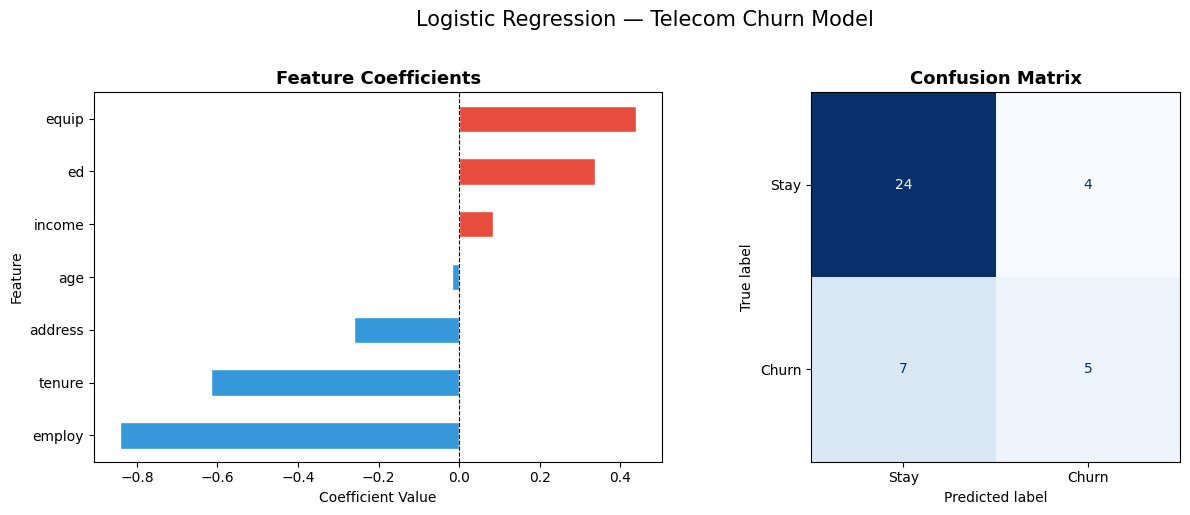

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Feature coefficients ──
coef_series = pd.Series(model.coef_[0], index=FEATURES).sort_values()
colors = ["#e74c3c" if v >= 0 else "#3498db" for v in coef_series]
coef_series.plot(kind="barh", ax=axes[0], color=colors, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Feature Coefficients", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Coefficient Value")
axes[0].set_ylabel("Feature")

# ── Confusion matrix ──
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stay", "Churn"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix", fontsize=13, fontweight="bold")

plt.suptitle("Logistic Regression — Telecom Churn Model", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 7 · Feature Importance Interpretation

- **Positive coefficient** → feature increases predicted churn probability
- **Negative coefficient** → feature decreases predicted churn probability
- **Larger absolute value** → stronger influence

In [8]:
importance = coef_series.abs().sort_values(ascending=False)
summary = pd.DataFrame({
    "Coefficient" : coef_series[importance.index].round(4),
    "Abs Value"   : importance.round(4),
    "Direction"   : ["↑ churn" if coef_series[f] > 0 else "↓ churn" for f in importance.index]
})
print(summary.to_string())

         Coefficient  Abs Value Direction
employ       -0.8426     0.8426   ↓ churn
tenure       -0.6155     0.6155   ↓ churn
equip         0.4405     0.4405   ↑ churn
ed            0.3385     0.3385   ↑ churn
address      -0.2617     0.2617   ↓ churn
income        0.0836     0.0836   ↑ churn
age          -0.0178     0.0178   ↓ churn


---
## Key Takeaways
- Logistic Regression achieves a **log loss < 0.55** on held-out data with only 7 features.
- **`equip`** (equipment type) and **`tenure`** (months as customer) are the strongest predictors of churn.
- StandardScaler is essential here — raw feature scales span orders of magnitude (income vs. ed level).
- Future improvements: feature engineering, SMOTE for class imbalance, or ensemble methods (Random Forest, XGBoost).